# Create file with $\langle SSHA \rangle_t$ 

In [1]:
import numpy as np
import pandas as pd
import xarray as xr
import dask.array as da

import matplotlib.pyplot as plt

import os
from glob import glob
from swot import browse_swot_250m, browse_swot_2km, add_grid_metrics,rotate_ggd
from cstes import swot_dir_2km, zarr_dir

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.geodesic as cgeo
crs = ccrs.PlateCarree()

import cartopy.geodesic as geod
import cartopy.crs as ccrs
import cartopy.feature as cfeature

______________
# Functions

In [2]:
dfs = browse_swot_2km().reset_index()
df3 = dfs[dfs.pass_number==3]
df16 = dfs[dfs.pass_number==16]

/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/dask/config.py:742: FutureWarning: Dask configuration key 'distributed.scheduler.transition-log-length' has been deprecated; please use 'distributed.admin.low-level-log-length' instead
  warnings.warn(
/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/dask/config.py:742: FutureWarning: Dask configuration key 'distributed.comm.recent-messages-log-length' has been deprecated; please use 'distributed.admin.low-level-log-length' instead
  warnings.warn(


In [25]:
def prepared_concat(ds):
    cn = ds.cycle_number.mean().values
    ds =ds.drop_vars('cycle_number')
    ds['cycle_number']=('cycle_number', [cn])
    return ds
#ds = xr.open_mfdataset(df.file.values, preprocess=prepared_concat)

In [29]:
ds3 = xr.open_mfdataset(df3.file.values, preprocess=prepared_concat)[['duacs_ssha_karin_2_filtered', 'duacs_ssha_karin_2_calibrated', 'duacs_editing_flag']]
ds16 = xr.open_mfdataset(df16.file.values, preprocess=prepared_concat)[['duacs_ssha_karin_2_filtered', 'duacs_ssha_karin_2_calibrated', 'duacs_editing_flag']]

/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/xarray/backends/plugins.py:159: RuntimeWarning: 'netcdf4' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)
/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/xarray/backends/plugins.py:159: RuntimeWarning: 'scipy' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)
/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/xarray/backends/plugins.py:159: RuntimeWarning: 'netcdf4' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)
/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/xarray/backends/plugins.py:159: RuntimeWarning: 'scipy' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)
/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/xarray/backends/plugins.py:159: Runt

In [30]:
ds3 = ds3.where(ds3.duacs_editing_flag==0)[['duacs_ssha_karin_2_filtered', 'duacs_ssha_karin_2_calibrated']]
ds16 = ds16.where(ds16.duacs_editing_flag==0)[['duacs_ssha_karin_2_filtered', 'duacs_ssha_karin_2_calibrated']]

In [31]:
ds3

<xarray.Dataset> Size: 53MB
Dimensions:                        (cycle_number: 94, num_lines: 496,
                                    num_pixels: 69)
Coordinates:
    latitude                       (num_lines, num_pixels) float64 274kB dask.array<chunksize=(496, 69), meta=np.ndarray>
    latitude_nadir                 (cycle_number, num_lines) float64 373kB dask.array<chunksize=(1, 496), meta=np.ndarray>
    longitude                      (num_lines, num_pixels) float64 274kB dask.array<chunksize=(496, 69), meta=np.ndarray>
    longitude_nadir                (cycle_number, num_lines) float64 373kB dask.array<chunksize=(1, 496), meta=np.ndarray>
    time                           (cycle_number, num_lines) datetime64[ns] 373kB dask.array<chunksize=(1, 496), meta=np.ndarray>
  * cycle_number                   (cycle_number) float64 752B 478.0 ... 578.0
Dimensions without coordinates: num_lines, num_pixels
Data variables:
    duacs_ssha_karin_2_filtered    (cycle_number, num_lines, num_pixels) float64 26MB dask.array<chunksize=(1, 496, 69), meta=np.ndarray>
    duacs_ssha_karin_2_calibrated  (cycle_number, num_lines, num_pixels) float64 26MB dask.array<chunksize=(1, 496, 69), meta=np.ndarray>
Attributes:
    latc:     39.961324
    lonc:     4.3749
    phi:      76.80931729750104

In [34]:
ds3m = ds3.rename({'duacs_ssha_karin_2_filtered':'mean_sshaf','duacs_ssha_karin_2_calibrated':'mean_sshac' }).mean('cycle_number').compute()
ds16m = ds16.rename({'duacs_ssha_karin_2_filtered':'mean_sshaf','duacs_ssha_karin_2_calibrated':'mean_sshac' }).mean('cycle_number').compute()

In [39]:
ds3m.to_netcdf(os.path.join(zarr_dir, 'before_coloc','preprocessed_swot','swot2km', f'pass3_swot2km_meanssha.nc'))
ds16m.to_netcdf(os.path.join(zarr_dir, 'before_coloc','preprocessed_swot','swot2km', f'pass16_swot2km_meanssha.nc'))

In [5]:
ds3m = xr.open_dataset(os.path.join(zarr_dir, 'before_coloc','preprocessed_swot','swot2km', f'pass3_swot2km_meanssha.nc'))
ds16m = xr.open_dataset(os.path.join(zarr_dir, 'before_coloc','preprocessed_swot','swot2km', f'pass16_swot2km_meanssha.nc'))

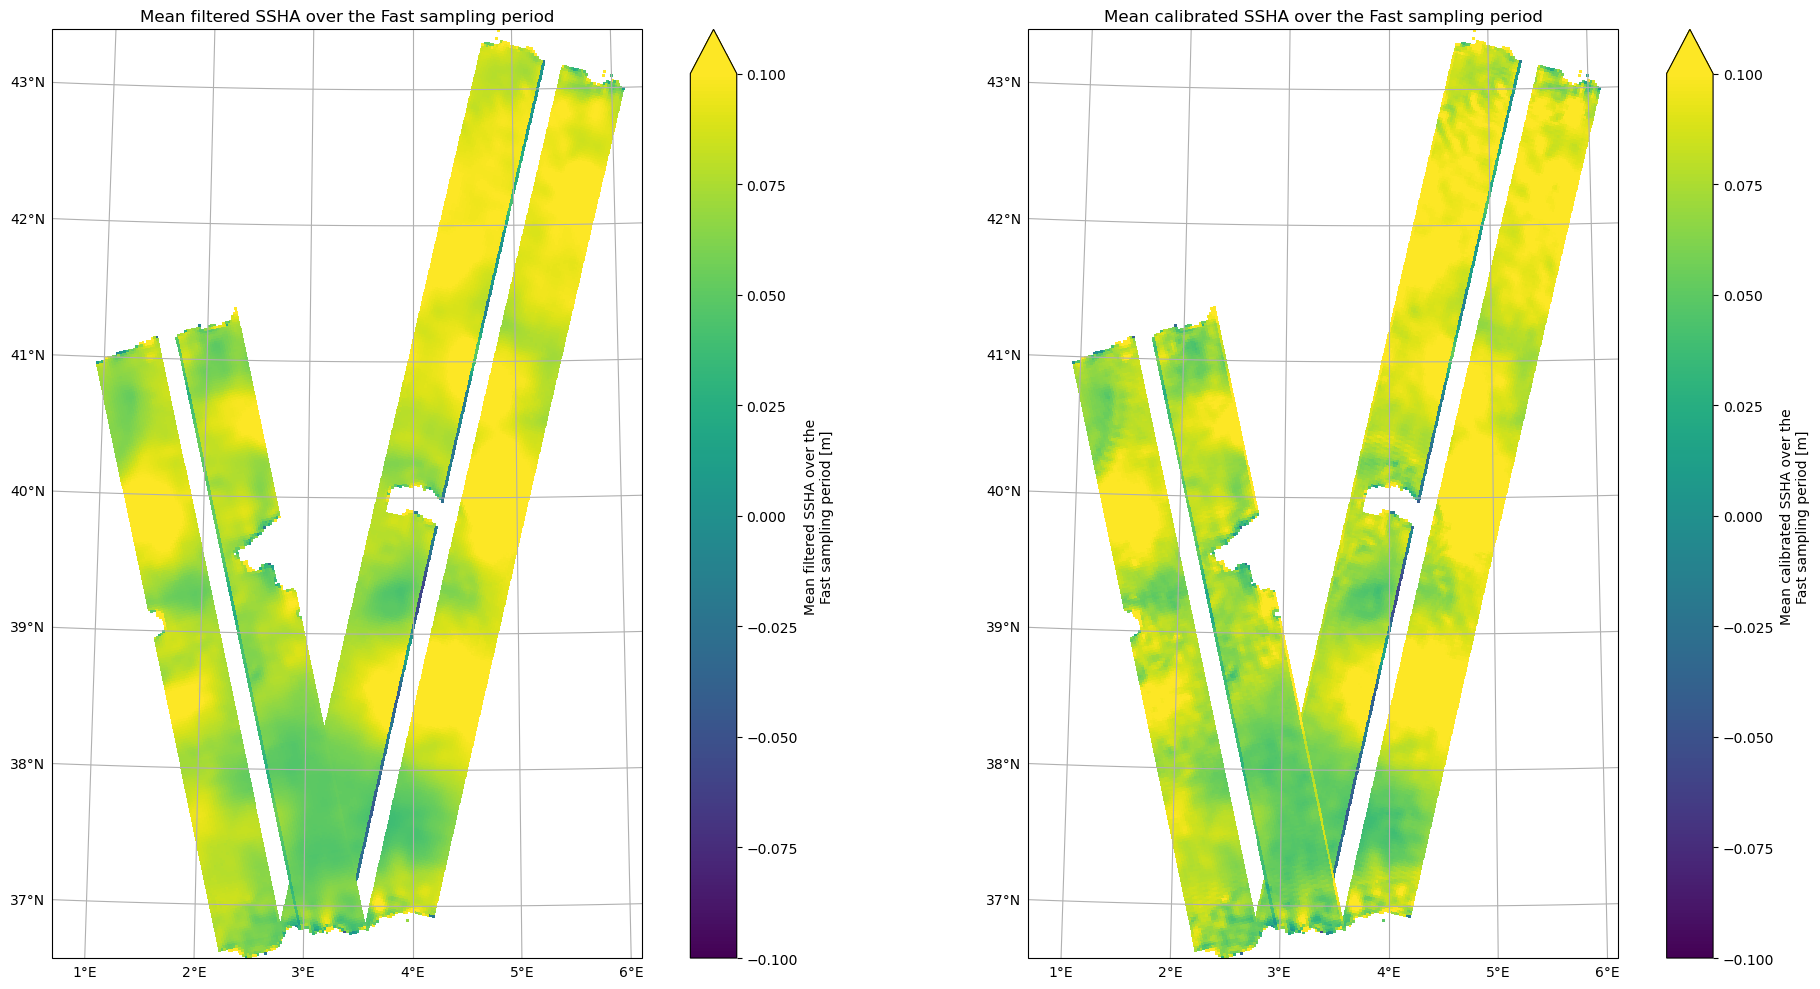

In [41]:
for ds in [ds3m, ds16m]:
    ds['mean_sshaf'] = ds['mean_sshaf'].assign_attrs({'long_name' :'Mean filtered SSHA over the Fast sampling period', 'units':'m'})
    ds['mean_sshac'] = ds['mean_sshac'].assign_attrs({'long_name' :'Mean calibrated SSHA over the Fast sampling period', 'units':'m'})


bbox = [0.7, 6.1, 36.6, 43.4]

fig = plt.figure(figsize=(20,10), frameon =False)
vmin, vmax = -0.1, 0.1

ax = fig.add_subplot(1,2,1, projection=ccrs.Orthographic(4,40))
ds3m.mean_sshaf.plot(x='longitude', y='latitude',ax=ax, transform=crs, vmin=vmin, vmax=vmax)
ds16m.mean_sshaf.plot(x='longitude', y='latitude',ax=ax, transform=crs, add_colorbar=False, vmin=vmin, vmax=vmax)
ax.set_title(f'Mean filtered SSHA over the Fast sampling period')
gl = ax.gridlines(draw_labels=True,)
ax.set_extent(bbox)
gl.top_labels = False
gl.right_labels = False


ax = fig.add_subplot(1,2,2, projection=ccrs.Orthographic(4,40))
ds3m.mean_sshac.plot(x='longitude', y='latitude',ax=ax, transform=crs, vmin=vmin, vmax=vmax)
ds16m.mean_sshac.plot(x='longitude', y='latitude',ax=ax, transform=crs, add_colorbar=False, vmin=vmin, vmax=vmax)
ax.set_title(f'Mean calibrated SSHA over the Fast sampling period')
gl = ax.gridlines(draw_labels=True,)
ax.set_extent(bbox)
gl.top_labels = False
gl.right_labels = False


fig.tight_layout()

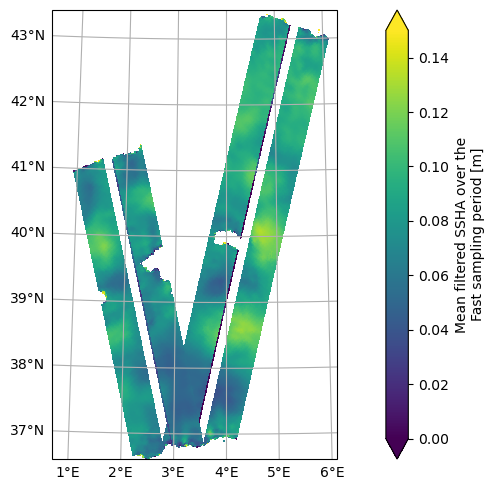

In [43]:
for ds in [ds3m, ds16m]:
    ds['mean_sshaf'] = ds['mean_sshaf'].assign_attrs({'long_name' :'Mean filtered SSHA over the Fast sampling period', 'units':'m'})
    ds['mean_sshac'] = ds['mean_sshac'].assign_attrs({'long_name' :'Mean calibrated SSHA over the Fast sampling period', 'units':'m'})


bbox = [0.7, 6.1, 36.6, 43.4]

fig = plt.figure(figsize=(10,5), frameon =False)
kwargs = dict( cmap='viridis', vmin=0, vmax=0.15)
ax = fig.add_subplot(1,1,1, projection=ccrs.Orthographic(4,40))
ds3m.mean_sshaf.plot(x='longitude', y='latitude',ax=ax, transform=crs,**kwargs)
ds16m.mean_sshaf.plot(x='longitude', y='latitude',ax=ax, transform=crs, add_colorbar=False, **kwargs)
#ax.set_title(f'Mean filtered SSHA over the Fast sampling period')
gl = ax.gridlines(draw_labels=True,)
ax.set_extent(bbox)
gl.top_labels = False
gl.right_labels = False

fig.tight_layout()


In [23]:
ds3m

<xarray.Dataset> Size: 1MB
Dimensions:    (num_lines: 496, num_pixels: 69)
Coordinates:
    latitude   (num_lines, num_pixels) float64 274kB ...
    longitude  (num_lines, num_pixels) float64 274kB ...
Dimensions without coordinates: num_lines, num_pixels
Data variables:
    mean_slaf  (num_lines, num_pixels) float64 274kB ...
    mean_slac  (num_lines, num_pixels) float64 274kB ...